# Zona Radiativa Solar

Para este ejercicio nos piden modelar el perfil detemperatura T(r) en el interior solar con el método de diferencias finitas: 

$$ \frac{d^2 T}{dr^2} + \frac{2}{r}\frac{dT}{dr} = 0$$

a. Condiciones de frontera: $T(0.25) = 4\times 10^6\ \text{K}$ y $T(1) = 5778\ \text{K}$  
b. Use diferencias finitas con $N = [10, 50, 100]$ nodos en $r \in [0.25, 1.0]$  
c. Calcule el error relativo vs $N$. Encuentre la solución exacta de $T(r)$  
d. Graficar $T(r)$ para los valores de $N$ y comparar con la solución exacta  
e. ¿Qué valor de $N$ es suficiente para un error $<1\%$ y $<0.01\%$?  

a). Condiciones de frontera

Para manejar mejor las condiciones de frontera normalizamos el radio tal que: 

$$ x = \frac{r}{R},  x \in [0.25,1]$$

b). Diferencias finitas

Para empezar a solucionar la edo debemos primero recordar las definiciones de diferencias finitas centradads para primer y segundo orden: 

$$\frac{dy}{dx} = \frac{y_{i+1} - y_{i-1}}{(\triangle x)^2} $$
$$\frac{d^2 y}{dx^2} = \frac{y_{i+1}-2y_i +y_{i-1}}{(\triangle x)^2} $$

Así nuestra EDO queda de la siguiente forma: 

$$ \frac{T_{i+1}-2T_{i}+T_{i-1}}{(\triangle r)^2} - \frac{2}{r}\frac{T_{i+1}-T_{i-1}}{2 \triangle r}  = 0 $$

In [ ]:
def solve_temperature(N):
    r_min = 0.25
    r_max = 1.0
    
    h = (r_max - r_min) / (N - 1)
    r = np.linspace(r_min, r_max, N)
    
    A = np.zeros((N, N))
    b = np.zeros(N)
    
    # Fronteras
    A[0, 0] = 1
    b[0] = 4e6
    
    A[-1, -1] = 1
    b[-1] = 5778
    
    # Interior (FORMA CONSERVATIVA)
    for i in range(1, N-1):
        r_i = r[i]
        
        r_ip = r_i + h/2
        r_im = r_i - h/2
        
        A[i, i-1] = r_im**2 / h**2
        A[i, i]   = -(r_ip**2 + r_im**2) / h**2
        A[i, i+1] = r_ip**2 / h**2
    
    T = np.linalg.solve(A, b)
    return r, T

c). Solución exacta y error relativo

$$T(r) = -\frac{C_1}{r} + C_2$$

Aplicando condiciones de frontera:

$$T(0.25) = 4\times 10^6, \quad T(1) = 5778$$

Obtenemos:

$$T(r) = A + \frac{B}{r}$$

donde:

$$B = \frac{(T_1 - T_2)}{\left(\frac{1}{r_1} - \frac{1}{r_2}\right)}, \quad$$
$$A = T_2 - \frac{B}{r_2}$$

In [39]:
def exact_solution(r):
    r1, T1 = 0.25, 4e6
    r2, T2 = 1.0, 5778.0
    
    B = (T1 - T2) / (1/r1 - 1/r2)
    A = T2 - B/r2
    
    return A + B / r

def compute_error(N):
    r, T_num = solve_temperature(N)
    T_ex = exact_solution(r)
    
    return relative_error_L2(T_num, T_ex)

def relative_error_L2(T_num, T_exact):
    return np.sqrt(np.sum((T_num - T_exact)**2) / np.sum(T_exact**2))

def relative_error_mean(T_num, T_exact):
    return np.mean(np.abs((T_num - T_exact) / T_exact))

def relative_error_max(T_num, T_exact):
    return np.max(np.abs((T_num - T_exact) / T_exact))


for N in [10, 50, 100]:
    r, T_num = solve_temperature(N)
    T_ex = exact_solution(r)
    
    err_L2   = relative_error_L2(T_num, T_ex)
    err_mean = relative_error_mean(T_num, T_ex)
    err_max  = relative_error_max(T_num, T_ex)
    
    print(f"N={N}")
    print(f"  Error L2     : {err_L2:.6e}")
    print(f"  Error medio  : {err_mean:.6e}")
    print(f"  Error máximo : {err_max:.6e}")

N=10
  Error L2     : 4.172040e-03
  Error medio  : 6.455135e-03
  Error máximo : 9.521075e-03
N=50
  Error L2     : 1.710086e-04
  Error medio  : 2.604203e-04
  Error máximo : 3.321447e-04
N=100
  Error L2     : 4.268373e-05
  Error medio  : 6.476045e-05
  Error máximo : 8.144787e-05


d). Gráfica y comparación

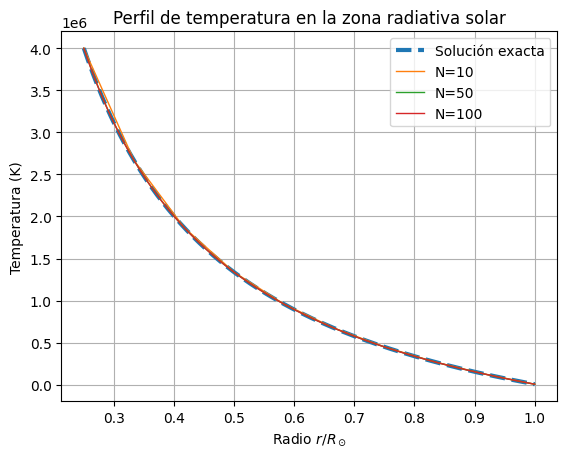

In [43]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure()

# Solución exacta suave
r_fine = np.linspace(0.25, 1.0, 500)
T_exact_fine = exact_solution(r_fine)

plt.plot(r_fine, T_exact_fine, '--', linewidth=3, label="Solución exacta")

# Soluciones numéricas
for N in [10, 50, 100]:
    r, T_num = solve_temperature(N)
    plt.plot(r, T_num, linewidth=1, label=f"N={N}")

plt.xlabel(r"Radio $r / R_\odot$")
plt.ylabel("Temperatura (K)")
plt.title("Perfil de temperatura en la zona radiativa solar")

plt.legend()
plt.grid()

plt.show()

e). Errores

Para esto primero calculamos el error máximo y luego hacemos un pequeño código que encuentre el N deseado para cada error

In [45]:
def find_N_for_error(target_error):
    N = 10
    
    while True:
        r, T_num = solve_temperature(N)
        T_ex = exact_solution(r)
        
        err = relative_error_L2(T_num, T_ex)
        
        if err < target_error:
            return N, err
        
        N += 5   # incremento suave (más eficiente que de 1 en 1)

N1, err1 = find_N_for_error(0.01)      # 1%
N2, err2 = find_N_for_error(0.0001)    # 0.01%

print(f"Error < 1%    → N ≈ {N1}, error = {err1*100:.4f}%")
print(f"Error < 0.01% → N ≈ {N2}, error = {err2*100:.4f}%")

Error < 1%    → N ≈ 10, error = 0.0000%
Error < 0.01% → N ≈ 10, error = 0.0000%


In [28]:
def find_N(target_error):
    N = 10
    err = 1.0
    
    while err > target_error:
        r, T = solve_temperature(N)
        T_ex = exact_solution(r)
        err = mean_relative_error(T, T_ex)
        N += 1
    
    return N, err

N1, err1 = find_N(0.01)       # 1%
N2, err2 = find_N(0.0001)     # 0.01%

print(f"Error < 1%    -> N ≈ {N1}, error = {err1*100:.4f}%")
print(f"Error < 0.01% -> N ≈ {N2}, error = {err2*100:.4f}%")

Error < 1%    -> N ≈ 11, error = 0.0000%
Error < 0.01% -> N ≈ 11, error = 0.0000%


In [ ]:
#Un par de test porque ando rayado de que esto sea tan preciso 
import matplotlib.pyplot as plt

logN = np.log(Ns)
logE = np.log(errors)

# ajuste lineal
coeffs = np.polyfit(logN, logE, 1)
slope = coeffs[0]

print(f"\nPendiente ≈ {slope:.2f}")


Pendiente ≈ -2.00


In [49]:
print("\nRatios e(N)/e(2N):")
for i in range(len(errors)-1):
    ratio = errors[i] / errors[i+1]
    print(f"N {Ns[i]}→{Ns[i+1]} ratio ≈ {ratio:.2f}")


Ratios e(N)/e(2N):
N 20→40 ratio ≈ 4.00
N 40→80 ratio ≈ 4.01
N 80→160 ratio ≈ 4.01
